---
## Import Libraries

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import math
import time

from tensorflow.keras.applications.vgg19 import VGG19, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model

In [ ]:
# Image Credits: Tensorflow Doc
content_path = tf.keras.utils.get_file(
  'content.jpg',
  'https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg')

style_path = tf.keras.utils.get_file(
  'style.jpg',
  'https://storage.googleapis.com/download.tensorflow.org/example_images/Vassily_Kandinsky%2C_1913_-_Composition_7.jpg')

83281/83281 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
195196/195196 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def load_and_process_image(image_path):
    img = load_img(image_path)
    img = img_to_array(img)
    img = preprocess_input(img)
    img = np.expand_dims(img, axis=0)

    return img

---
## Preprocess

In [ ]:
def deprocess(img):
    img[:, :, 0] += 103.939
    img[:, :, 1] += 116.779
    img[:, :, 2] += 123.68

    img = img[:, :, ::-1]

    img = np.clip(img, 0, 255).astype(np.uint8)
    return img

def display_image(image):
    if len(image.shape) == 4:
        img = np.squeeze(image, axis=0)

    img = deprocess(img)

    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img)
    return

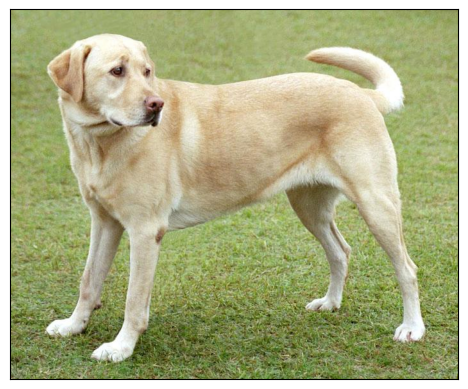

In [ ]:
content_img = load_and_process_image(content_path)
display_image(content_img)

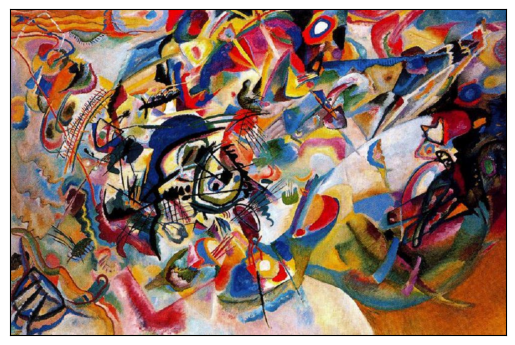

In [ ]:
style_img = load_and_process_image(style_path)
display_image(style_img)

---
## Model Initialization

In [ ]:
model = VGG19(
    include_top=False,
    weights='imagenet'
)
content_layer = 'block5_conv2'
content_model = Model(inputs = model.input,
                      outputs = model.get_layer(content_layer).output)

content_model.summary()

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 15,304,768 (58.38 MB)

 Trainable params: 15,304,768 (58.38 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
style_layers = [
    'block1_conv1',
    'block2_conv1',
    'block3_conv1',
    'block4_conv1',
    'block5_conv1'
]

style_models = [Model(inputs=model.input,
                      outputs=model.get_layer(layer).output)for layer in style_layers]

#### content loss

In [ ]:
def content_loss(content, generated):
    a_C = content_model(content)
    a_G = content_model(generated)
    loss = tf.reduce_mean(tf.square(a_C - a_G))
    return loss

#### gram matrix

In [ ]:
def gram_matrix(A):
    channels = int(A.shape[-1])
    a = tf.reshape(A, [-1, channels])
    n = tf.shape(a)[0]
    gram = tf.matmul(a,a,transpose_a = True)
    return gram/tf.cast(n, tf.float32)

weight_of_layer =  1./len(style_layers)

#### style cost

In [ ]:
def style_cost(style, generated):
    J_style = 0

    for style_model in style_models:
        a_style = style_model(style)
        a_generated = style_model(generated)
        gram_a_style = gram_matrix(a_style)
        gram_a_generated = gram_matrix(a_generated)
        content_cost = tf.reduce_mean(tf.square(gram_a_generated - gram_a_style ))
        J_style += content_cost + weight_of_layer # bisa di ganti pake "*" instead of "+"

    return J_style

#### content loss

In [ ]:
def content_cost(style, generated):
    J_content = 0

    for style_model in style_models:
        a_style = style_model(style)
        a_generated = style_model(generated)
        gram_a_style = gram_matrix(a_style)
        gram_a_generated = gram_matrix(a_generated)
        content_cost = tf.reduce_mean(tf.square(gram_a_style - gram_a_generated))
        J_content += content_cost + weight_of_layer # bisa di ganti pake "*" instead of "+"

    return J_content

---
## Training Functions

In [ ]:
generated_images = []

def training_loop(content_path, style_path, iterations, a=10, b=1000):
    content = load_and_process_image(content_path)
    style = load_and_process_image(style_path)
    generated = tf.Variable(content, dtype = tf.float32)

    opt = tf.keras.optimizers.Adam(learning_rate=0.7)
    best_cost = math.inf
    best_image = None

    for i in range (iterations):
        start_time_cpu = time.process_time()
        start_time_wall = time.time()
        with tf.GradientTape() as tape:
            J_content = content_cost(style, generated)
            J_style = style_cost(style, generated)
            J_total = a * J_content + b * J_style

        grads = tape.gradient(J_total, generated)
        opt.apply_gradients([(grads, generated)])

        end_time_cpu = time.process_time()
        end_time_wall = time.time()
        cpu_time = end_time_cpu - start_time_cpu
        wall_time = end_time_wall - start_time_wall

        if J_total  < best_cost:
            best_cost = J_total
            best_image = generated.numpy()

        print("CPU times: user {} µs, sys: {} ns, total: {} µs".format(
          int(cpu_time * 1e6),
          int(( end_time_cpu - start_time_cpu) * 1e9),
          int((end_time_cpu - start_time_cpu + 1e-6) * 1e6))
             )

        print("Wall time: {:.2f} µs".format(wall_time * 1e6))
        print("Iteration :{}".format(i))
        print('Total Loss {:e}.'.format(J_total))
        generated_images.append(generated.numpy())

    return best_image

In [ ]:
final_image = training_loop(content_path, style_path, iterations=1500)

Streaming output truncated to the last 5000 lines.
CPU times: user 1350364 µs, sys: 1350364399 ns, total: 1350365 µs
Wall time: 1952793.12 µs
Iteration :250
Total Loss 1.748825e+12.
CPU times: user 1336808 µs, sys: 1336808761 ns, total: 1336809 µs
Wall time: 1964926.00 µs
Iteration :251
Total Loss 1.739780e+12.
CPU times: user 1346973 µs, sys: 1346973894 ns, total: 1346974 µs
Wall time: 1965784.55 µs
Iteration :252
Total Loss 1.730820e+12.
CPU times: user 1390414 µs, sys: 1390414339 ns, total: 1390415 µs
Wall time: 1983509.06 µs
Iteration :253
Total Loss 1.721938e+12.
CPU times: user 1345554 µs, sys: 1345554914 ns, total: 1345555 µs
Wall time: 1962765.22 µs
Iteration :254
Total Loss 1.713132e+12.
CPU times: user 1330371 µs, sys: 1330371259 ns, total: 1330372 µs
Wall time: 1963393.69 µs
Iteration :255
Total Loss 1.704409e+12.
CPU times: user 1353969 µs, sys: 1353969962 ns, total: 1353970 µs
Wall time: 1967145.68 µs
Iteration :256
Total Loss 1.695769e+12.
CPU times: user 1436948 µs, sys:

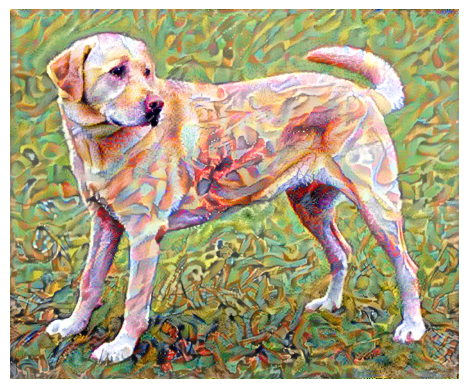

In [ ]:
# Tampilkan dengan matplotlib
import matplotlib.pyplot as plt

def display_image(img_array):
    if len(img_array.shape) == 4:
        img_array = np.squeeze(img_array, axis=0)
    img = deprocess(img_array)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

last_generated = generated_images[-1]

# Ayo kita lihat hasil terakhir
display_image(last_generated)
